In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy

In [2]:
stokes_surface = 1 # [m/s]
delta_z = np.arange(0.0001, 2.5, 0.01)

T_p_values = [5, 10, 20]
decay_stokes_vel = {}

for T_p in T_p_values:
    omega_p = 2. * np.pi / T_p
    k_p = (omega_p ** 2) / 9.81

    jj = 2 * k_p * np.abs(delta_z)
    # Decay function based on Equation A.6 of Li et al. (2017)
    decay_func = 1/(2*k_p) * (
        1 - np.exp(-jj)
        - 2/3 * (1 + np.sqrt(np.pi) * jj**(3/2) * scipy.special.erfc(np.sqrt(jj))
        - (1 + jj) * np.exp(-jj))
    )

    j0 = 2 * k_p * np.abs(0)
    decay_func_0 = 1/(2*k_p) * (
        1 - np.exp(-j0)
        - 2/3 * (1 + np.sqrt(np.pi) * j0**(3/2) * scipy.special.erfc(np.sqrt(j0))
        - (1 + j0) * np.exp(-j0))
    )

    decay_stokes_vel[T_p] = (stokes_surface * decay_func - stokes_surface * decay_func_0) / (0 - (-delta_z))

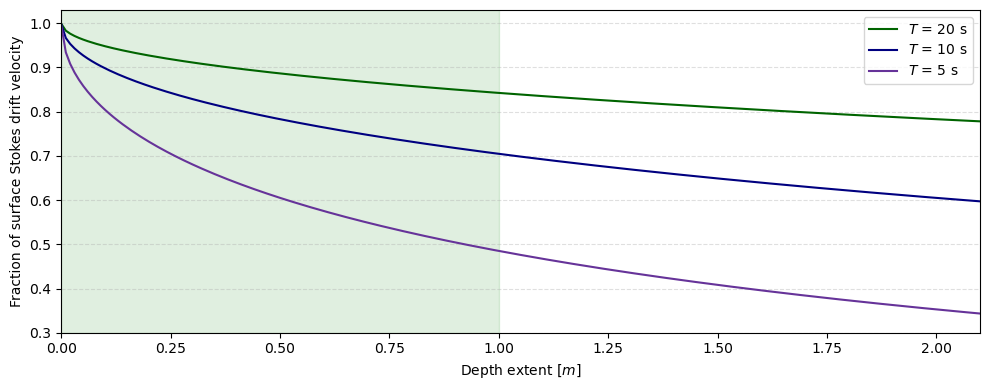

In [3]:

fig, (ax1) = plt.subplots(1, 1, figsize=(10, 4))
plt.axvspan(0, 1, color='green', alpha=0.12)

ax1.plot(delta_z , decay_stokes_vel[20] ,"-", label='$T$ = 20 s', color = 'darkgreen')
ax1.plot(delta_z , decay_stokes_vel[10] ,"-", label='$T$ = 10 s', color = 'navy')
ax1.plot(delta_z , decay_stokes_vel[5], "-" , label='$T$ = 5 s', color = 'rebeccapurple')
ax1.set_xlabel(r'Depth extent [$m$]')
ax1.set_ylabel('Fraction of surface Stokes drift velocity')
ax1.grid(alpha=0.4, linestyle='--', axis='y')
ax1.set_xlim(0, 2.1)
ax1.set_ylim(0.3,1.03)
ax1.legend(loc='upper right')

plt.tight_layout()
plt.savefig("FigureA1.pdf", format="pdf", bbox_inches="tight")
plt.show()